# Passive Membrane Dynamics

This notebook derives, simulates, and validates the passive neural membrane model.

- The membrane equation is:

$$
C_m\frac{dV}{dt}=I_0-g_L(V-E_L)
,
\qquad g_L=\frac{1}{R_m}.
$$

- For constant injected current 

$$
\tau_m=R_mC_m,
\qquad
V_\infty=E_L+R_mI_0.
$$

- Therefore,

$$
\frac{dV}{dt}
=
-\frac{V-V_\infty}{\tau_m}.
$$

- All calculations use SI units. Figures display time in ms and voltage in mV.

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

e_l = -65e-3       # V
v0 = -65e-3        # V
r_m = 100e6        # ohm
c_m = 200e-12      # F
i0 = 100e-12       # A

tau = r_m * c_m
v_inf = i0 * r_m + e_l

print(f'tau = {tau * 1e3} ms')
print(f'V_inf = {v_inf * 1e3} mV')


tau = 20.0 ms
V_inf = -55.0 mV


## Analytical solution 

- For the initial condition $V(0)=V_0$ the exact solution is:

$$
V(t)=V_\infty+(V_0-V_\infty)e^{-t/\tau_m}
$$

- The distance from equilibrium decays exponentially:

$$
V(t)-V_\infty=(V_0-V_\infty)e^{-t/\tau_m}\\
$$




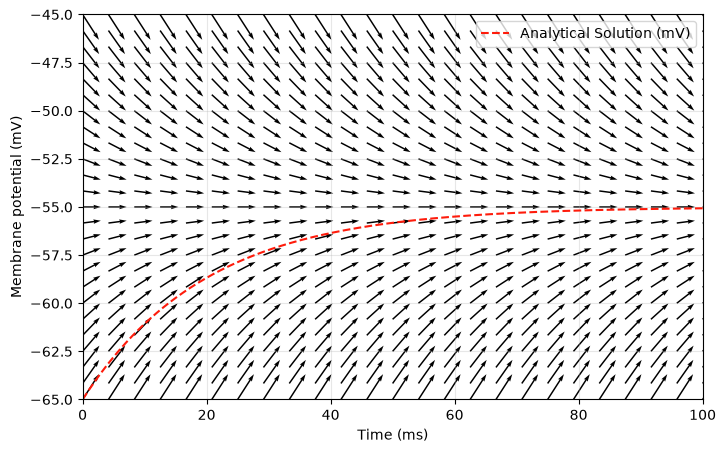

In [3]:
def dv(v, v_inf, tau):
    return -(v - v_inf)/tau
    
def passive_voltage(t, v0, v_inf, tau):
    return v_inf + (v0 - v_inf) * np.exp(-t/tau)

t = np.linspace(0, 0.1, 500)
y = passive_voltage(t, v0, v_inf, tau)


t_plot = np.linspace(0, 100, 25)
v = np.linspace(-65, -45, 25)
T, V = np.meshgrid(t_plot, v)

X = np.ones_like(T)
Y = dv(V, v_inf * 1e3, tau * 1e3)
N = np.sqrt(X**2 + Y**2)
X = X/N
Y = Y/N

plt.figure(figsize=(8, 5))
plt.quiver(T, V, X, Y, scale_units = 'xy', angles = 'xy', scale = 0.34)
plt.xlim(0, 100)
plt.ylim(-65, -45)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.grid(alpha = 0.3)
plt.plot(t * 1e3, y * 1e3, '--', label = 'Analytical Solution (mV)', color = "#FE1B0B")
plt.legend()
plt.show()

    

## Euler simulation

- Euler's method approximates the membrane equation using:

$$
V_{n+1}
=
V_n+\Delta t\frac{V_\infty-V_n}{\tau_m}
$$

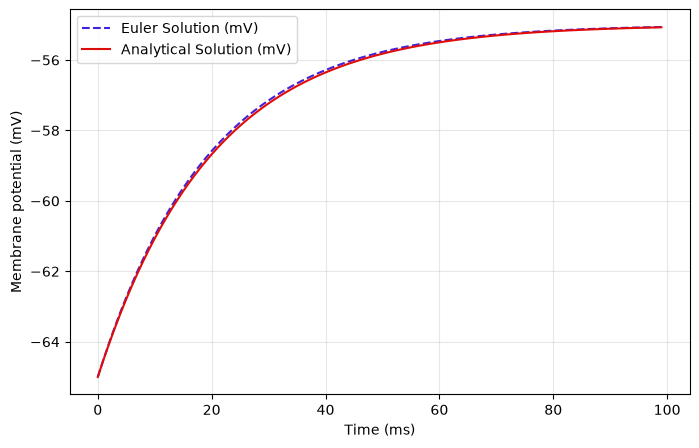

Maximum Error: 0.09393518762901287 mV


In [4]:
dt = 1e-3
t_end = 0.1  
time = np.arange(0, t_end, dt)
v_euler = np.empty_like(time)
v_euler[0] = v0

for i in range(time.shape[0]-1):
    v_euler[i+1] = v_euler[i] + dt * dv(v_euler[i], v_inf, tau)

v_analytical = passive_voltage(time, v0, v_inf, tau)

plt.figure(figsize=(8, 5))
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.plot(time * 1e3, v_euler * 1e3, '--', label = 'Euler Solution (mV)', color = "#4420D6")
plt.plot(time * 1e3, v_analytical * 1e3, label = 'Analytical Solution (mV)', color = "#DF0D09")
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

er = np.max(np.abs(v_analytical - v_euler))
print(f'Maximum Error: {er * 1e3} mV')





In [5]:
dts = np.array([1, 0.5, 0.1, 0.05, 0.01]) * 1e-3
t_end = 0.1
maximum_errors = []

for dt in dts:
    time = np.arange(0, t_end, dt)
    v_euler = np.empty_like(time)
    v_euler[0] = v0

    for i in range(time.shape[0]-1):
        v_euler[i+1] = v_euler[i] + dt * dv(v_euler[i], v_inf, tau)

    v_analytical = passive_voltage(time, v0, v_inf, tau)
    er = np.max(np.abs(v_analytical - v_euler))
    maximum_errors.append(er * 1e3)

maximum_errors = np.array(maximum_errors)
print(f'Maximum Errors: {maximum_errors}')

Maximum Errors: [0.09393519 0.04647001 0.00921619 0.00460329 0.00091989]


$$ 
E \propto dt^p 
$$

$$
E = k\,dt^p \\[0.3cm]
$$

$$
log(E) = log(k) + p \, log(dt) \\
$$

$$
x = log(dt), \,\,\, y = log(E), \,\,\, K = log(k) \\
$$

$$
y = K + p \, x
$$


p = 1.0042914527353863
k = 96.27369950032269
E             : [0.09346162 0.04659201 0.00925426 0.00461339 0.00091633]
Maximum Errors: [0.09393519 0.04647001 0.00921619 0.00460329 0.00091989]


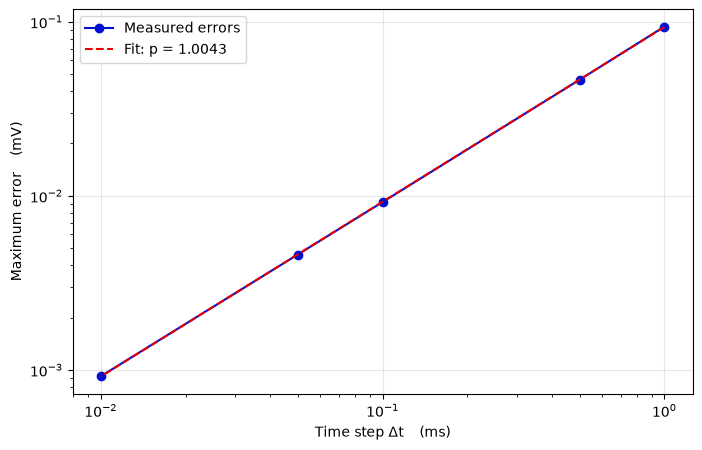

In [6]:
p, K = np.polyfit(np.log(dts), np.log(maximum_errors), 1)
k = np.exp(K)
print(f'p = {p}')
print(f'k = {k}')

E = k * dts**p
print(f'E             : {E}')
print(f'Maximum Errors: {maximum_errors}')


plt.figure(figsize=(8, 5))
plt.loglog(dts * 1e3, maximum_errors, 'o-', label = 'Measured errors', color = "#0011D1")
plt.loglog(dts * 1e3, E, '--', label = f'Fit: p = {p:.4f}', color = "#E80000")
plt.legend()
plt.xlabel('Time step Δt    (ms)')
plt.ylabel('Maximum error    (mV)')
plt.grid(alpha = 0.3)
plt.show()


# Euler's Method Stability

$$
\frac{dv}{dt} = -\frac{v - v_\infty}{\tau_m} \\[0.4cm]
$$

$$
E = v - v_\infty\, , \,\,\,\, v_\infty \,\, is \,\, constant\\[0.4cm]
$$

$$
\frac{dE}{dt} = \frac{dv}{dt} \\[0.4cm]
$$

$$
\frac{dE}{dt} = - \frac{E}{\tau_m} \\[0.4cm]
$$

$$
E_1 = E_0 - dt \, \frac{E_0}{\tau_m} \\[0.4cm]
$$

$$
E_1 = E_0 (1 - \frac{dt}{\tau_m}) \\[0.4cm]
$$

$$
E_2 = E_1 (1 - \frac{dt}{\tau_m}) ==> E_2 = E_0 (1 - \frac{dt}{\tau_m})^2 \\[0.4cm]
$$

$$
E_n = E_0 (1 - \frac{dt}{\tau_m})^n \\[0.4cm]
$$


- For the error to decay, $1 - dt/τ_m$ should be smaller than 1 and bigger than -1:


$$
 -1 < 1 - \frac{dt}{\tau_m} < 1 \\[0.2cm]
$$

$$
 -2 <-\frac{dt}{\tau_m} < 0 \\[0.2cm]
$$

$$
 2 > \frac{dt}{\tau_m} > 0 \\[0.2cm]
$$

$$
 2\tau_m > dt > 0 \\[0.2cm]
$$

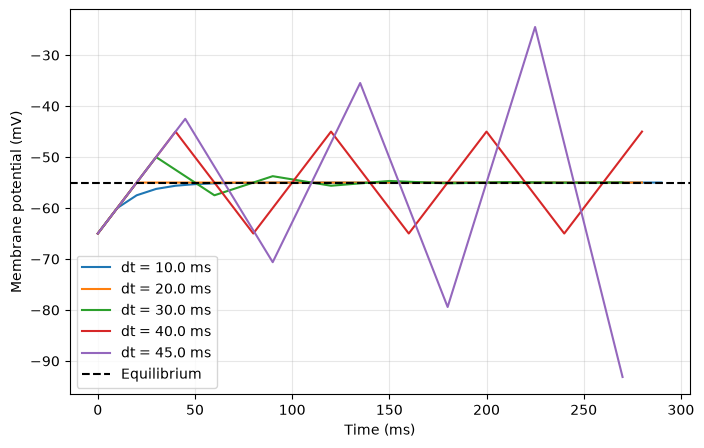

In [7]:
# tau is 20ms
dts = np.array([10, 20, 30, 40, 45]) * 1e-3  
t_end = 0.3
plt.figure(figsize=(8, 5))
for dt in dts:
    time = np.arange(0, t_end, dt)
    v_euler = np.empty_like(time)
    v_euler[0] = v0

    for i in range(time.shape[0]-1):
        v_euler[i+1] = v_euler[i] + dt * dv(v_euler[i], v_inf, tau)

    plt.plot(time * 1e3, v_euler* 1e3, label = f'dt = {dt * 1e3} ms')

plt.axhline(v_inf * 1e3, linestyle = '--', label = 'Equilibrium', color = 'black')
plt.legend()
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.grid(alpha = 0.3)
plt.show()